# Employee Attrition Prediction — HR Analytics

**Data Scientist Portfolio Project**

## 1. Business Understanding

Employee attrition imposes significant costs on companies: recruitment costs,
onboarding costs, lost productivity, and loss of institutional knowledge. Companies want to
understand **what factors drive employees to resign** and **build a predictive model**
to identify employees at high risk of leaving so that the HR team can implement
retention interventions early on.

**Problem Statement**
> Can we predict whether an employee will resign (`Attrition`) based on
> their demographic attributes, compensation, job satisfaction, and career history?

**Objectives**
1. Perform *data cleaning* and *exploratory data analysis* (EDA) to understand attrition patterns.
2. Build several classification models (Logistic Regression, Random Forest, XGBoost).
3. Perform *hyperparameter tuning* to improve model performance.
4. Evaluate the models using metrics appropriate for *imbalanced* data (Precision, Recall, F1, ROC-AUC).
5. Extract *feature importance* and translate it into business recommendations for HR.

**Dataset**: HR Analytics dataset, 1,480 employee rows, 37 attribute columns.



## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42


## 3. Data Loading

The dataset is loaded from an Excel file `HR_Analytics-4.xlsx`.

In [2]:
df = pd.read_excel('HR_Analytics-4.xlsx')
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
df.head()


Jumlah baris: 1480, Jumlah kolom: 37


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome(KM),Education,EducationField,...,RelationshipSatisfaction,StandardWorkingHours,StockOptionLevel,TotalExperience(Years),TrainingsLastYear,WorkLifeBalance,YearsatCompany,YearsinCurrentRole,YearsSincePromotion,YearsWithCurrManager
0,VK2970,19,18-25,Yes,Travel_Rarely,230,Administration,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,VK3020,19,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,VK4580,19,18-25,Yes,Travel-Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,VK7280,19,18-25,No,Non-Travel,287,Administration,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,VK8290,19,18-25,Yes,Non-Travel,247,Administration,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome(KM)      1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  JobInvol

## 4. Data Cleaning

Data cleaning steps:
1. Check for duplicate values and missing values.
2. Remove columns with constant or uninformative values (`Over18`, `EmployeeCount`,
   `StandardWorkingHours`) — these columns are the same for all rows and therefore do not contribute
   to the model.
3. Remove identifier columns (`EmpID`, `EmployeeNumber`) that are irrelevant to the prediction.
4. Handle missing values in the `YearsWithCurrManager` column.

In [4]:
# Check for duplicate
print("Count of duplicate rows:", df.duplicated().sum())

# Check missing value
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nColumns with missing values:")
print(missing)


Count of duplicate rows: 2

Columns with missing values:
YearsWithCurrManager    61
dtype: int64


In [5]:
# Check columns with constant values (not informative)
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns:", constant_cols)


Constant columns: ['EmployeeCount', 'Over18', 'StandardWorkingHours']


In [6]:
# Handle missing value on YearsWithCurrManager -> fill with median
median_val = df['YearsWithCurrManager'].median()
df['YearsWithCurrManager'] = df['YearsWithCurrManager'].fillna(median_val)
print(f"Missing value filled with median: {median_val}")

# Drop constant columns and non-informative identifiers for the model
cols_to_drop = constant_cols + ['EmpID', 'EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop)

print(f"\nRows removed: {cols_to_drop}")
print(f"Shape after cleaning: {df_clean.shape}")


Missing value filled with median: 3.0

Rows removed: ['EmployeeCount', 'Over18', 'StandardWorkingHours', 'EmpID', 'EmployeeNumber']
Shape after cleaning: (1480, 32)


In [7]:
# Make sure there are no missing values left
assert df_clean.isnull().sum().sum() == 0, "Still have missing values!"
print("Data is clean, no missing values.")
df_clean.head()


Data is clean, no missing values.


,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome(KM),Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalExperience(Years),TrainingsLastYear,WorkLifeBalance,YearsatCompany,YearsinCurrentRole,YearsSincePromotion,YearsWithCurrManager
0,19,18-25,Yes,Travel_Rarely,230,Administration,3,3,Life Sciences,3,...,3,3,0,0,2,3,0,0,0,0.0
1,19,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,4,...,3,1,0,0,2,3,0,0,0,0.0
2,19,18-25,Yes,Travel-Frequently,1306,Sales,5,3,Marketing,2,...,3,4,0,0,3,3,0,0,0,0.0
3,19,18-25,No,Non-Travel,287,Administration,5,2,Life Sciences,2,...,3,4,0,0,2,3,0,0,0,0.0
4,19,18-25,Yes,Non-Travel,247,Administration,8,1,Medical,3,...,3,4,0,0,0,3,0,0,0,0.0


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Distribution: Attrition

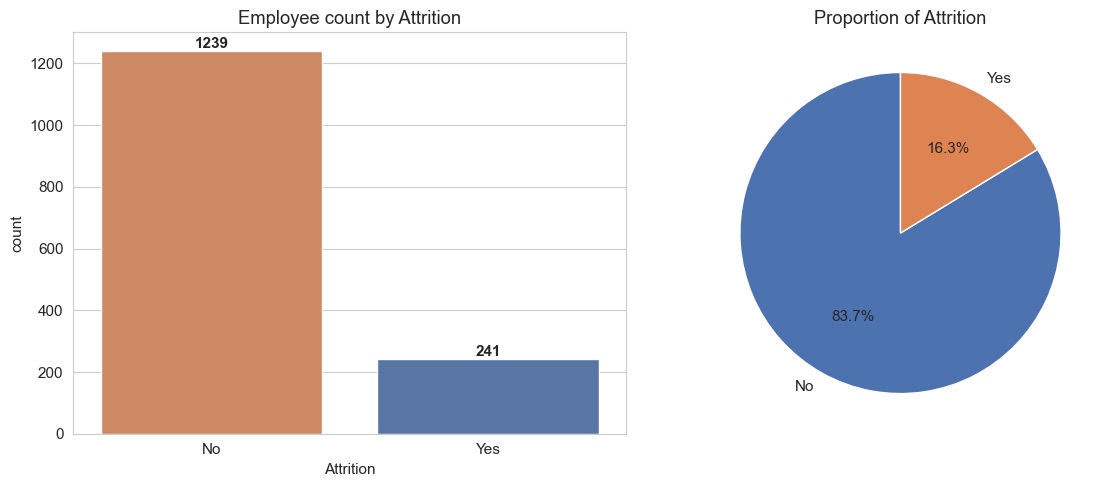

Attrition Rate: 16.28%

>> Dataset is IMBALANCED (~84% No vs ~16% Yes).
>> This is important: accuracy alone is not sufficient for model evaluation, we need Precision/Recall/F1/ROC-AUC.


In [8]:
attr_counts = df_clean['Attrition'].value_counts()
attr_pct = df_clean['Attrition'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='Attrition', hue='Attrition', palette=['#4C72B0', '#DD8452'],
              order=['No', 'Yes'], legend=False, ax=ax[0])
ax[0].set_title('Employee count by Attrition')
for i, v in enumerate(attr_counts.reindex(['No', 'Yes'])):
    ax[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

ax[1].pie(attr_pct.reindex(['No', 'Yes']), labels=['No', 'Yes'], autopct='%1.1f%%',
          colors=['#4C72B0', '#DD8452'], startangle=90)
ax[1].set_title('Proportion of Attrition')

plt.tight_layout()
plt.show()

print(f"Attrition Rate: {attr_pct['Yes']:.2f}%")
print("\n>> Dataset is IMBALANCED (~84% No vs ~16% Yes).")
print(">> This is important: accuracy alone is not sufficient for model evaluation, we need Precision/Recall/F1/ROC-AUC.")


### 5.2 Attrition by Department & Job Role

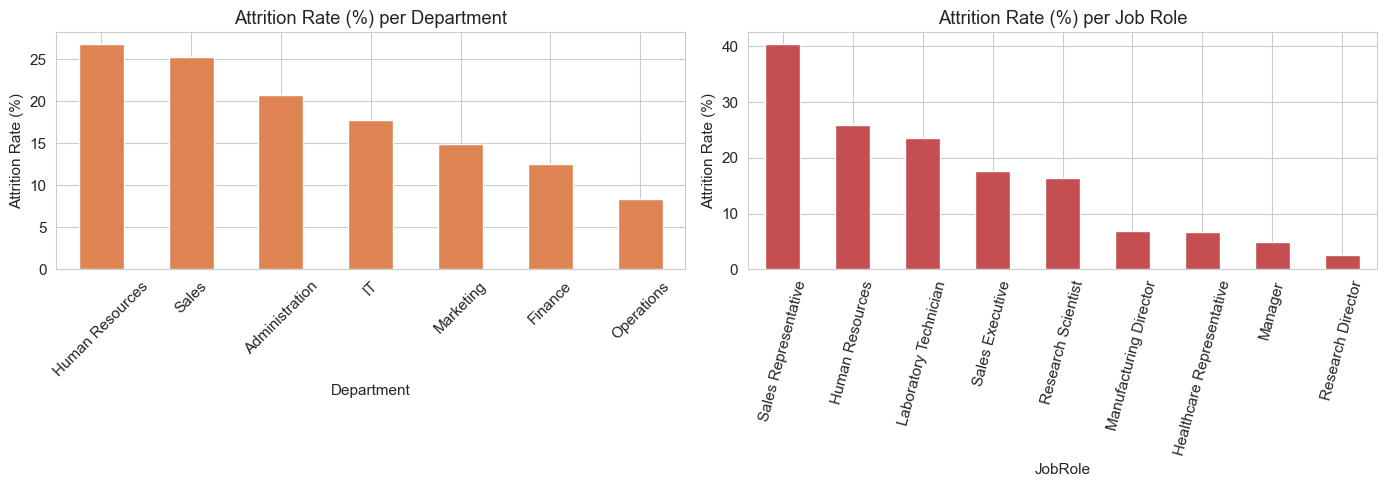

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

dept_attr = pd.crosstab(df_clean['Department'], df_clean['Attrition'], normalize='index') * 100
dept_attr['Yes'].sort_values(ascending=False).plot(kind='bar', ax=ax[0], color='#DD8452')
ax[0].set_title('Attrition Rate (%) per Department')
ax[0].set_ylabel('Attrition Rate (%)')
ax[0].tick_params(axis='x', rotation=45)

role_attr = pd.crosstab(df_clean['JobRole'], df_clean['Attrition'], normalize='index') * 100
role_attr['Yes'].sort_values(ascending=False).plot(kind='bar', ax=ax[1], color='#C44E52')
ax[1].set_title('Attrition Rate (%) per Job Role')
ax[1].set_ylabel('Attrition Rate (%)')
ax[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()


### 5.3 Job Satisfaction Factors & Working Conditions vs. Attrition

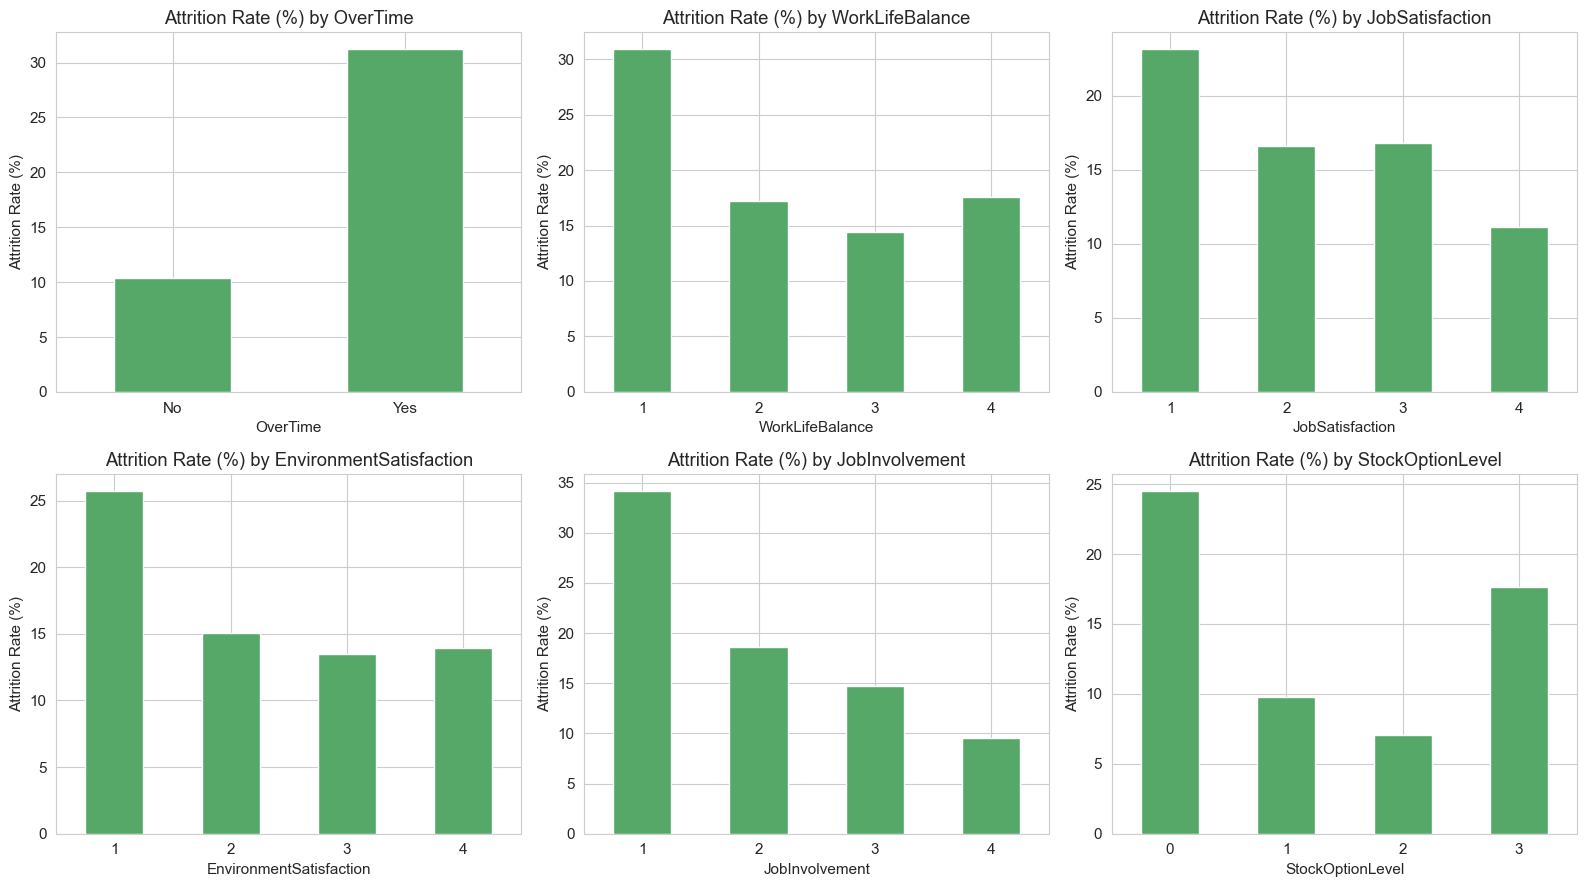

Insight: employees with OverTime='Yes' and low satisfaction/involvement scores
tend to have much higher attrition rates.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

factors = ['OverTime', 'WorkLifeBalance', 'JobSatisfaction',
           'EnvironmentSatisfaction', 'JobInvolvement', 'StockOptionLevel']

for i, factor in enumerate(factors):
    r, c = divmod(i, 3)
    ct = pd.crosstab(df_clean[factor], df_clean['Attrition'], normalize='index') * 100
    ct['Yes'].plot(kind='bar', ax=axes[r, c], color='#55A868')
    axes[r, c].set_title(f'Attrition Rate (%) by {factor}')
    axes[r, c].set_ylabel('Attrition Rate (%)')
    axes[r, c].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Insight: employees with OverTime='Yes' and low satisfaction/involvement scores")
print("tend to have much higher attrition rates.")


### 5.4 Numeric Distribution: Age, Income, Distance, Tenure vs Attrition

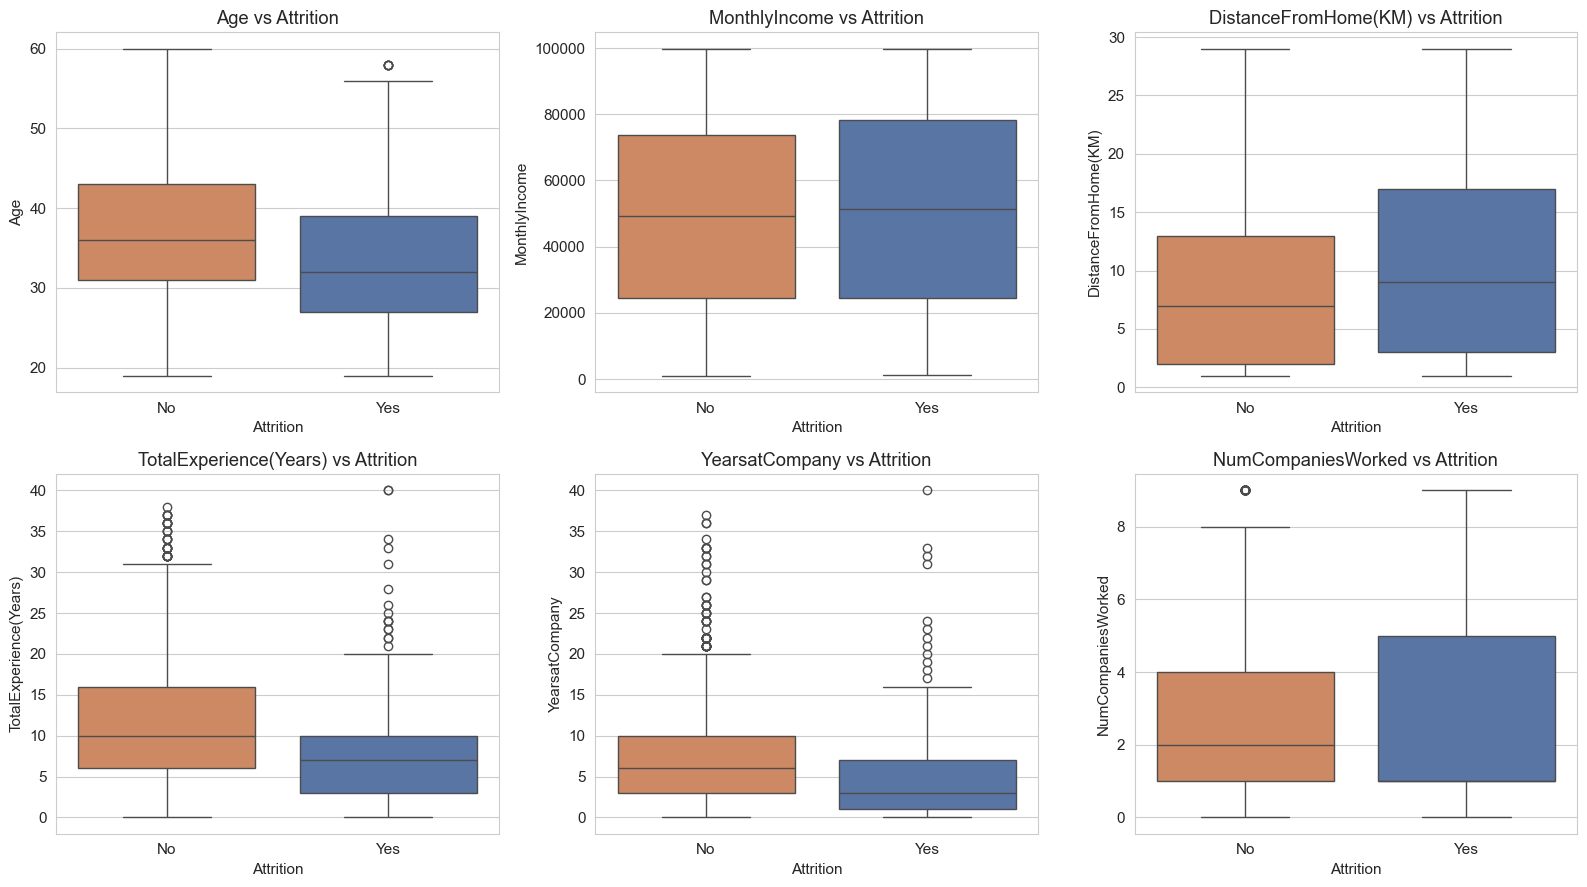

In [11]:
num_factors = ['Age', 'MonthlyIncome', 'DistanceFromHome(KM)',
               'TotalExperience(Years)', 'YearsatCompany', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, factor in enumerate(num_factors):
    r, c = divmod(i, 3)
    sns.boxplot(data=df_clean, x='Attrition', y=factor, hue='Attrition',
                order=['No', 'Yes'], palette=['#4C72B0', '#DD8452'], legend=False, ax=axes[r, c])
    axes[r, c].set_title(f'{factor} vs Attrition')

plt.tight_layout()
plt.show()


### 5.5 Correlation Heatmap (Numeric Feature)

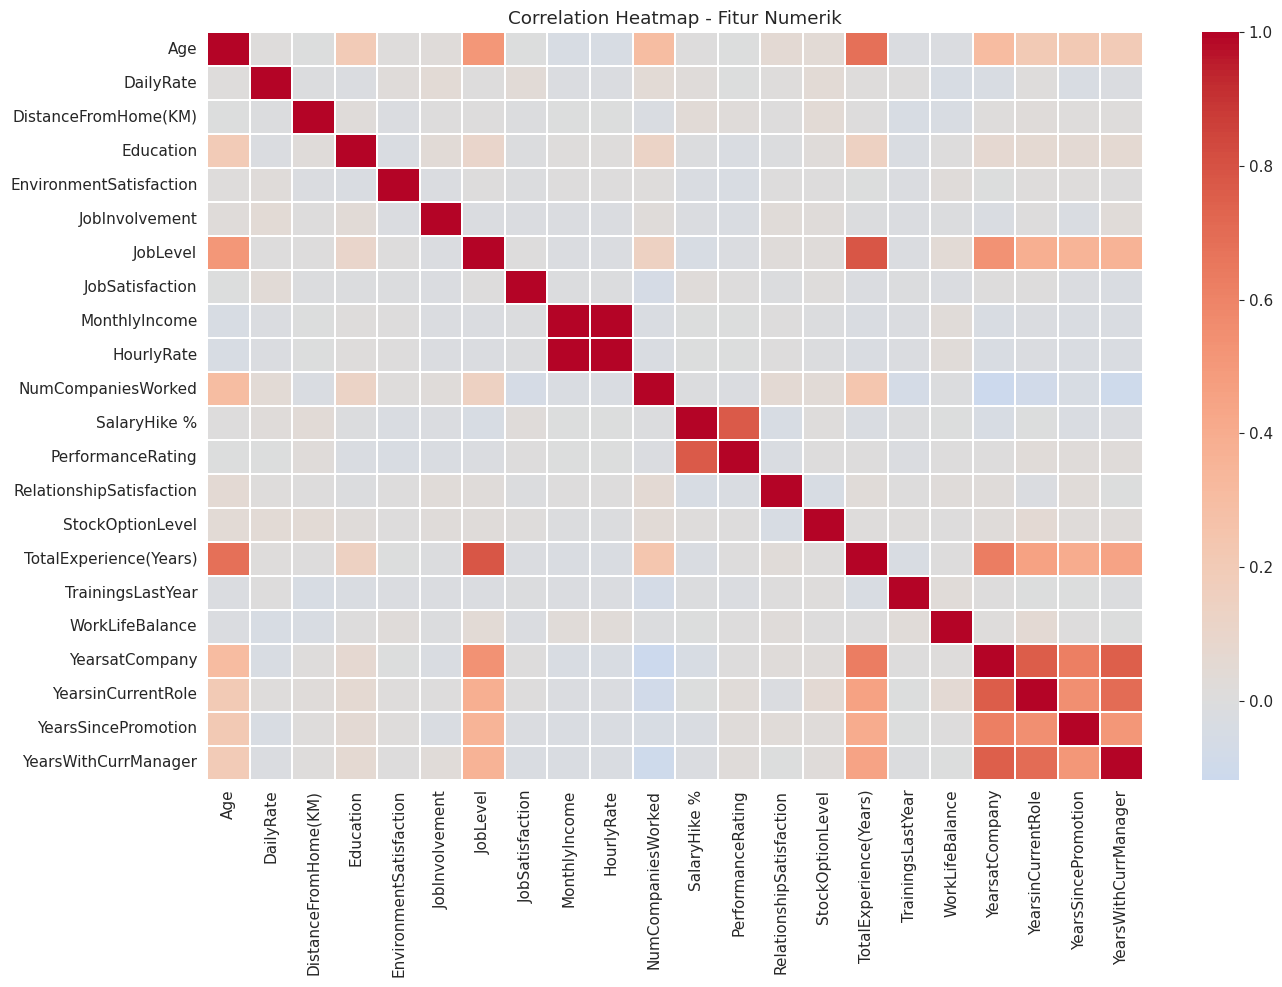

In [12]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap - Fitur Numerik')
plt.tight_layout()
plt.show()


### 5.6 Summary of EDA Insights

- **The overall attrition rate is approximately 16%** — the data is imbalanced.
- **Overtime = Yes** is strongly associated with a higher attrition rate.
- Low scores for **Work-Life Balance, Job Satisfaction, and Environment Satisfaction** tend to
  increase attrition.
- Employees who are **young** and have **short tenures** (low `YearsatCompany`)
  are more likely to resign.
- Certain **departments/job roles** have attrition rates well above average,
  which warrants special attention from the HR team.


## 6. Feature Engineering

Steps:
1. Encoding the target `Attrition` (Yes=1, No=0).
2. Encoding categorical features (Label Encoding for ordinal/binary features, One-Hot Encoding
   for nominal features with multiple categories).
3. Split the data into training and test sets (80/20, stratified due to class imbalance).
4. Scale numerical features.
5. Address *class imbalance* using SMOTE on the training data.


In [12]:
data = df_clean.copy()

# Encode the target
data['Attrition'] = data['Attrition'].map({'No': 0, 'Yes': 1})

# Categorical columns
cat_cols = data.select_dtypes(include=['object', 'string']).columns.tolist()
print("Categorical columns:", cat_cols)


Categorical columns: ['AgeGroup', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'SalarySlab', 'OverTime']


In [13]:
# Binary encoding for columns with 2 categories
binary_cols = [c for c in cat_cols if data[c].nunique() == 2]
for c in binary_cols:
    le = LabelEncoder()
    data[c] = le.fit_transform(data[c])
print("Binary-encoded:", binary_cols)

# One-hot encoding for nominal columns with >2 categories
multi_cat_cols = [c for c in cat_cols if c not in binary_cols]
print("One-hot encoded:", multi_cat_cols)

data = pd.get_dummies(data, columns=multi_cat_cols, drop_first=True)
print("\nShape after encoding:", data.shape)


Binary-encoded: ['Gender', 'MaritalStatus', 'OverTime']
One-hot encoded: ['AgeGroup', 'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'SalarySlab']

Shape after encoding: (1480, 55)


In [14]:
X = data.drop(columns=['Attrition'])
y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTarget distribution in the training set:")
print(y_train.value_counts(normalize=True))


Train shape: (1184, 54) | Test shape: (296, 54)

Target distribution in the training set:
Attrition
0    0.836993
1    0.163007
Name: proportion, dtype: float64


In [15]:
# Scaling numeric features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


In [17]:
# Handling class imbalance with SMOTE (only on data training)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Target distribution before SMOTE:", y_train.value_counts().to_dict())
print("Target distribution after SMOTE :", y_train_res.value_counts().to_dict())


Target distribution before SMOTE: {0: 991, 1: 193}
Target distribution after SMOTE : {0: 991, 1: 991}


## 7. Modeling

Three models will be built and compared:
1. **Logistic Regression** — baseline, interpretable.
2. **Random Forest** — captures nonlinear relationships.
3. **XGBoost** — gradient boosting, typically performs best on tabular data.

The `evaluate_model` helper function was created so that all models are evaluated using consistent metrics.


In [18]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Confusion Matrix - {name}')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='#C44E52')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve - {name}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        'model': name,
        'f1': f1_score(y_test, y_pred),
        'roc_auc': auc
    }

results = []


### 7.1 Logistic Regression (Baseline)

===== Logistic Regression =====
              precision    recall  f1-score   support

          No       0.93      0.80      0.86       248
         Yes       0.40      0.71      0.52        48

    accuracy                           0.78       296
   macro avg       0.67      0.75      0.69       296
weighted avg       0.85      0.78      0.80       296

ROC-AUC: 0.8335


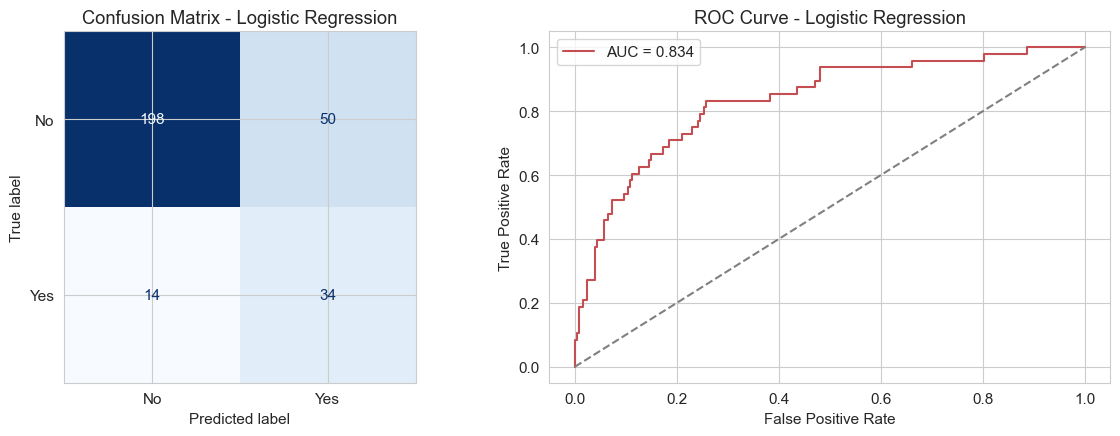

In [19]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_res, y_train_res)

results.append(evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test))


### 7.2 Random Forest

===== Random Forest =====
              precision    recall  f1-score   support

          No       0.87      0.98      0.92       248
         Yes       0.72      0.27      0.39        48

    accuracy                           0.86       296
   macro avg       0.80      0.63      0.66       296
weighted avg       0.85      0.86      0.84       296

ROC-AUC: 0.8452


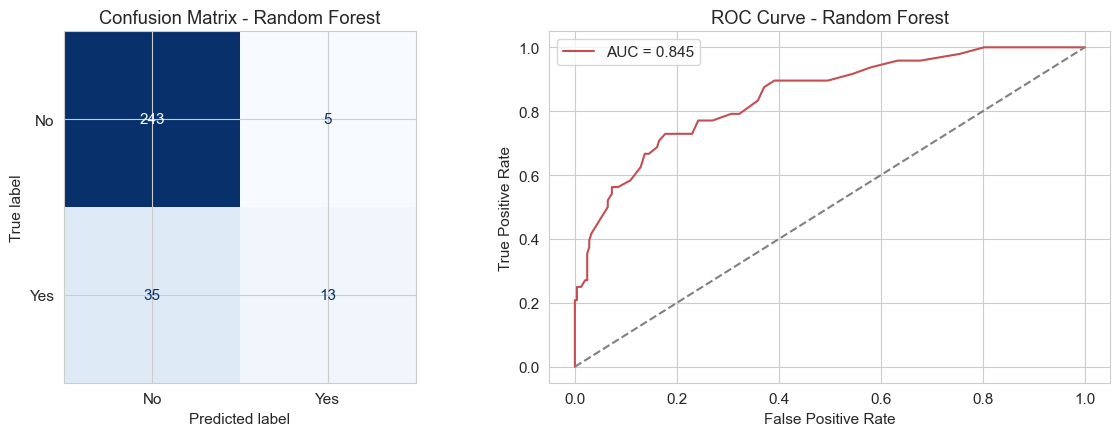

In [20]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

results.append(evaluate_model('Random Forest', rf, X_test_scaled, y_test))


### 7.3 XGBoost

===== XGBoost =====
              precision    recall  f1-score   support

          No       0.88      0.95      0.92       248
         Yes       0.59      0.35      0.44        48

    accuracy                           0.85       296
   macro avg       0.74      0.65      0.68       296
weighted avg       0.84      0.85      0.84       296

ROC-AUC: 0.8350


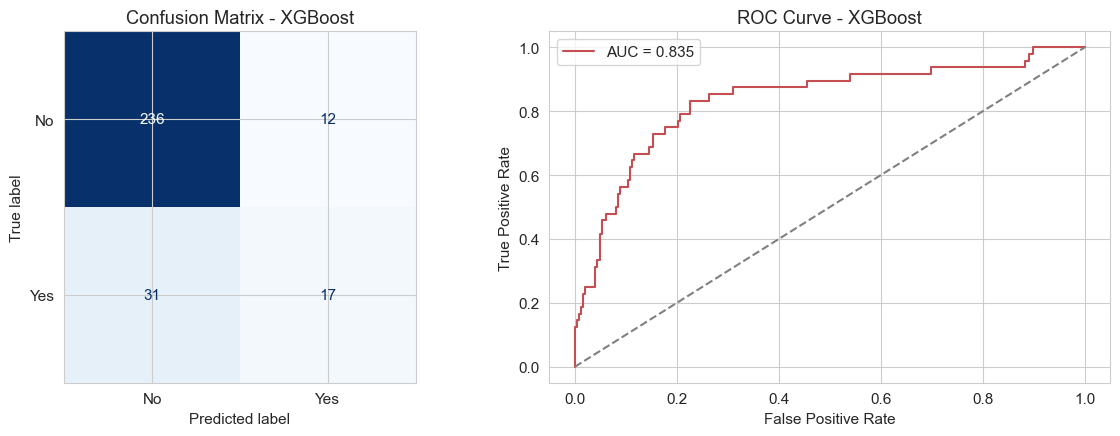

In [21]:
xgb = XGBClassifier(
    random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1
)
xgb.fit(X_train_res, y_train_res)

results.append(evaluate_model('XGBoost', xgb, X_test_scaled, y_test))


### 7.4 Comparison of Initial Models

                 model        f1   roc_auc
1        Random Forest  0.393939  0.845220
2              XGBoost  0.441558  0.835013
0  Logistic Regression  0.515152  0.833501


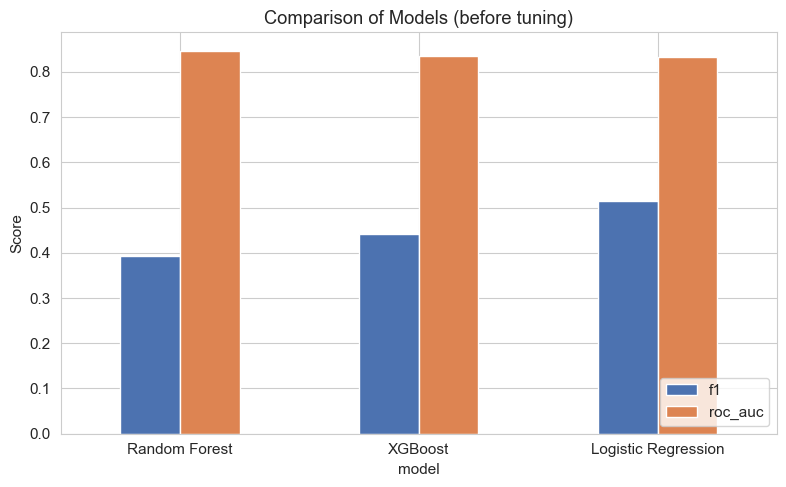

In [22]:
results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
print(results_df)

results_df.set_index('model')[['f1', 'roc_auc']].plot(kind='bar', figsize=(8, 5), color=['#4C72B0', '#DD8452'])
plt.title('Comparison of Models (before tuning)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning

The models with the best performance in the initial stage were further tuned using `GridSearchCV`
with stratified cross-validation (`StratifiedKFold`), optimized for **ROC-AUC**
since this metric is the most representative for imbalanced data.

Tuning was performed on **Random Forest** and **XGBoost**—the two models with the best performance.


In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


### 8.1 Tuning Random Forest

Best params (RF): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV ROC-AUC (RF): 0.9858
===== Random Forest (Tuned) =====
              precision    recall  f1-score   support

          No       0.87      0.99      0.93       248
         Yes       0.80      0.25      0.38        48

    accuracy                           0.87       296
   macro avg       0.84      0.62      0.65       296
weighted avg       0.86      0.87      0.84       296

ROC-AUC: 0.8520


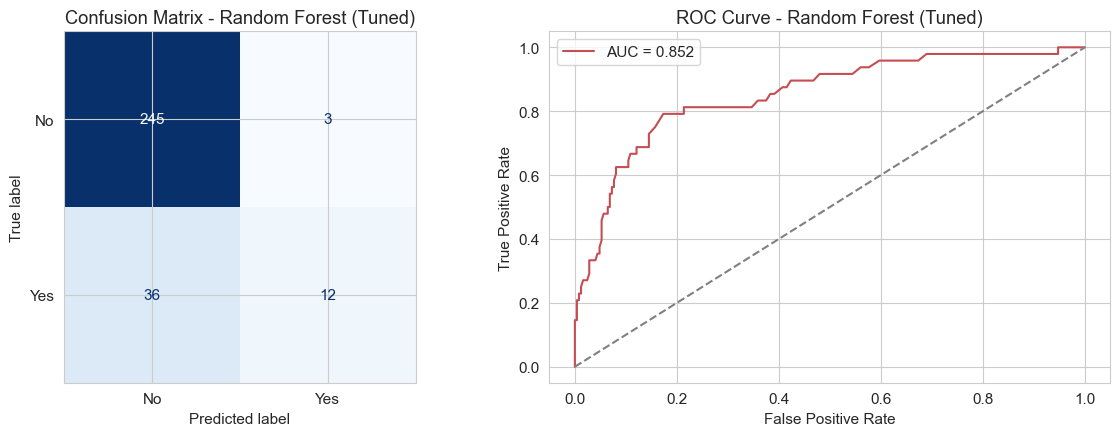

In [24]:
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train_res, y_train_res)

print("Best params (RF):", rf_grid.best_params_)
print("Best CV ROC-AUC (RF):", round(rf_grid.best_score_, 4))

rf_best = rf_grid.best_estimator_
results.append(evaluate_model('Random Forest (Tuned)', rf_best, X_test_scaled, y_test))


### 8.2 Tuning XGBoost

Best params (XGB): {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC (XGB): 0.9816
===== XGBoost (Tuned) =====
              precision    recall  f1-score   support

          No       0.88      0.96      0.92       248
         Yes       0.64      0.33      0.44        48

    accuracy                           0.86       296
   macro avg       0.76      0.65      0.68       296
weighted avg       0.84      0.86      0.84       296

ROC-AUC: 0.8425


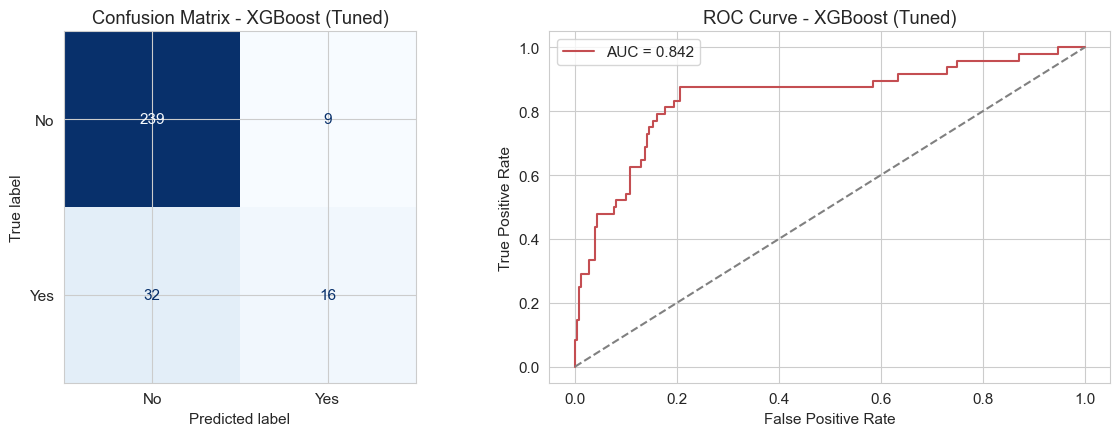

In [25]:
xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1),
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train_res, y_train_res)

print("Best params (XGB):", xgb_grid.best_params_)
print("Best CV ROC-AUC (XGB):", round(xgb_grid.best_score_, 4))

xgb_best = xgb_grid.best_estimator_
results.append(evaluate_model('XGBoost (Tuned)', xgb_best, X_test_scaled, y_test))


### 8.3 Comparison of All Models (Before and After Tuning)

                   model        f1   roc_auc
0  Random Forest (Tuned)  0.380952  0.852025
1          Random Forest  0.393939  0.845220
2        XGBoost (Tuned)  0.438356  0.842490
3                XGBoost  0.441558  0.835013
4    Logistic Regression  0.515152  0.833501


<Figure size 1000x500 with 0 Axes>

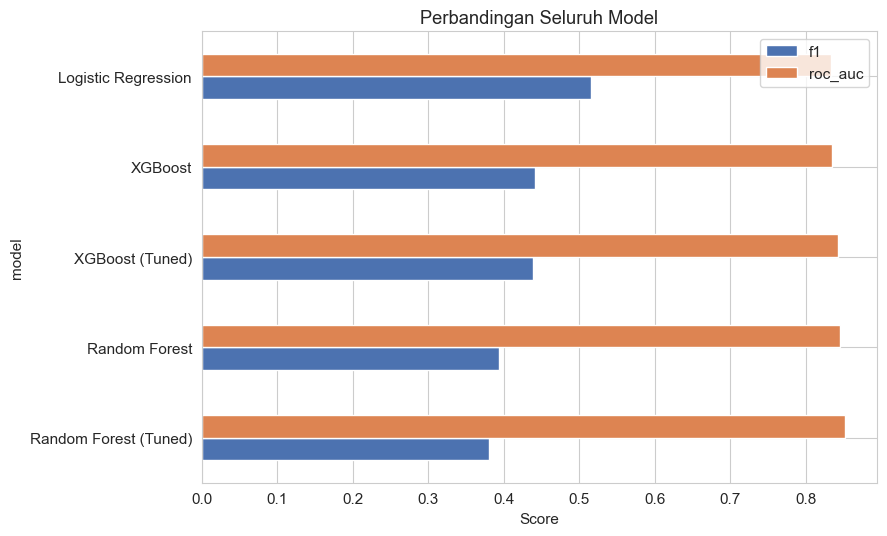


>> Best model based on ROC-AUC: Random Forest (Tuned)


In [27]:
final_results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(final_results_df)

plt.figure(figsize=(10, 5))
final_results_df.set_index('model')[['f1', 'roc_auc']].plot(kind='barh', figsize=(9, 5.5), color=['#4C72B0', '#DD8452'])
plt.title('Perbandingan Seluruh Model')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

best_model_name = final_results_df.iloc[0]['model']
print(f"\n>> Best model based on ROC-AUC: {best_model_name}")


## 9. Feature Importance

Extract the features that have the greatest influence on attrition predictions from the best tree-based
model (Random Forest / XGBoost after tuning).


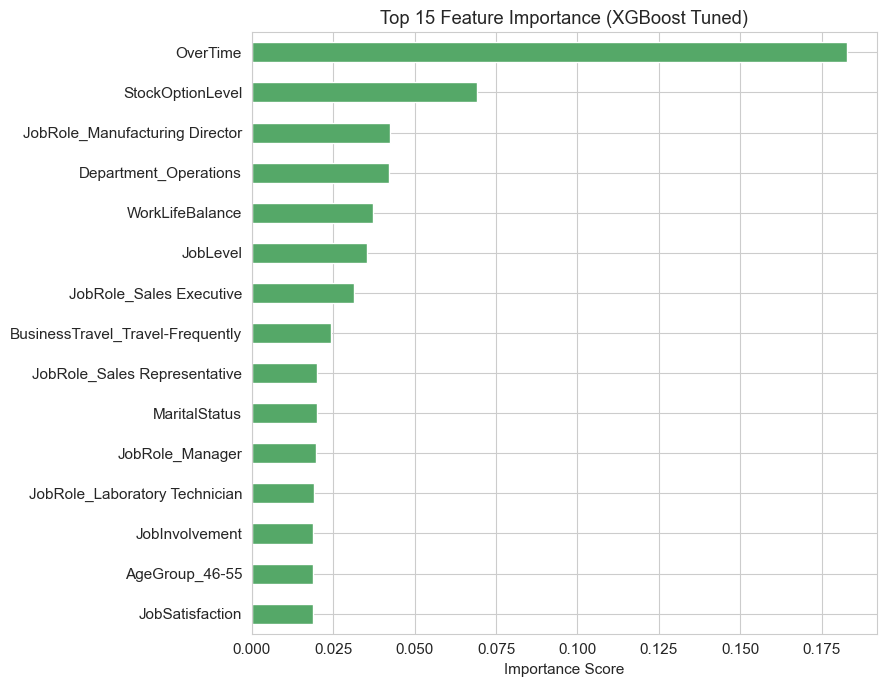

OverTime                            0.182842
StockOptionLevel                    0.069128
JobRole_Manufacturing Director      0.042322
Department_Operations               0.042171
WorkLifeBalance                     0.037163
JobLevel                            0.035218
JobRole_Sales Executive             0.031456
BusinessTravel_Travel-Frequently    0.024278
JobRole_Sales Representative        0.020149
MaritalStatus                       0.019881
JobRole_Manager                     0.019750
JobRole_Laboratory Technician       0.019056
JobInvolvement                      0.018886
AgeGroup_46-55                      0.018829
JobSatisfaction                     0.018751
dtype: float32


In [28]:
importances = xgb_best.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
feat_imp.sort_values().plot(kind='barh', color='#55A868')
plt.title('Top 15 Feature Importance (XGBoost Tuned)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp)


## 10. Conclusions & Business Recommendations

### Model Conclusions
- The best model was selected based on **ROC-AUC** because the attrition data is imbalanced
  (±16% Yes vs. ±84% No), so accuracy alone can be misleading.
- *Hyperparameter tuning* for Random Forest and XGBoost successfully improved performance
  compared to the baseline model (Logistic Regression).
- Features such as **OverTime, MonthlyIncome, Age, TotalExperience, JobSatisfaction, and
  YearsatCompany** consistently emerged as strong predictors of attrition, in line with the findings
  from the EDA phase.

### Recommendations for the HR Team
1. **Manage overtime** — reevaluate the workload for teams or roles with high levels of
   overtime, as this is strongly correlated with the risk of resignation.
2. **Review compensation** for income levels or roles with high attrition — consider
   salary adjustments or additional benefits.
3. **Retention programs for new hires** — employees with low `YearsatCompany` are more
   likely to leave; consider stronger onboarding and mentoring programs during the first 1–2
   years.
4. **Improve job satisfaction and work-life balance** — through regular surveys, work flexibility,
   and clear career development paths.
5. **Use this predictive model** as an *early-warning system* — it assigns an attrition risk score
   to each employee so the HR team can intervene proactively, rather than reactively.

### Limitations & Future Directions
- The dataset is cross-sectional (single point in time); the analysis would be stronger with
  multi-period historical data.
- The model can be further improved using techniques such as *cost-sensitive learning*,
  ensembling, or the exploration of interaction features.
- For production use, the model needs to be *deployed* (e.g., via Streamlit or Flask API) and
  its performance monitored periodically (*model drift*).
